# Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data

In [2]:
data = pd.read_csv("C:/skripsi/rev6_apr/data_ori/train_ori_6apr.csv")
Y = data["Harga_Asli"]
X = data.drop(columns=["Harga_Asli"])
X.drop(columns=["latitude","longitude"], inplace=True)

In [3]:
Y.info()
print("\n===============================================================\n")
X.info()

<class 'pandas.core.series.Series'>
RangeIndex: 916 entries, 0 to 915
Series name: Harga_Asli
Non-Null Count  Dtype  
--------------  -----  
916 non-null    float64
dtypes: float64(1)
memory usage: 7.3 KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 80 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   kecamatan                          916 non-null    object 
 1   bedroom                            916 non-null    int64  
 2   bathrooms                          916 non-null    int64  
 3   jumlah_guest_toilet                916 non-null    int64  
 4   lantai                             916 non-null    int64  
 5   area_digunakan                     916 non-null    int64  
 6   luas_tanah                         916 non-null    int64  
 7   dist_SD                            916 non-null    float64
 8   dist_SMP                           916 non

# Cek dist = 0

In [4]:
# Ambil semua kolom jarak
dist_cols = [col for col in X.columns if col.startswith("dist_") or col.startswith("akses_")]

# Hitung jumlah nilai 0
zero_check = pd.DataFrame({
    "Kolom": dist_cols,
    "Jumlah_0": [ (X[col] == 0).sum() for col in dist_cols ],
    "Persentase_0 (%)": [
        round((X[col] == 0).mean() * 100, 2) for col in dist_cols
    ]
}).sort_values("Jumlah_0", ascending=False)

zero_check


,Kolom,Jumlah_0,Persentase_0 (%)
0,dist_SD,0,0.0
1,dist_SMP,0,0.0
2,dist_SMA_SMK,0,0.0
3,dist_Universitas,0,0.0
4,dist_Fasilitas_Kesehatan,0,0.0
5,dist_Mall,0,0.0
6,dist_Supermarket,0,0.0
7,dist_Minimarket,0,0.0
8,dist_Stasiun,0,0.0
9,dist_Terminal,0,0.0


# Perhitungan korelasi

## Pearson Correlation

In [5]:
continuous_cols = [
    "bedroom",
    "bathrooms",
    "jumlah_guest_toilet",
    "lantai",
    "area_digunakan",
    "luas_tanah",
    "dist_SD",
    "dist_SMP",
    "dist_SMA_SMK",
    "dist_Universitas",
    "dist_Fasilitas_Kesehatan",
    "dist_Mall",
    "dist_Supermarket",
    "dist_Minimarket",
    "dist_Stasiun",
    "dist_Terminal",
    "dist_Bandara",
    "dist_Halte",
    "dist_Entry_Exit_Tol"
]

# Ambil hanya kolom yang dihitung
X_num_continuous = X[continuous_cols]
corr_pearson_X = X_num_continuous.corr(method="pearson")

In [6]:
# Threshold korelasi tinggi
threshold = 0.7
corr_pairs = (
    corr_pearson_X.abs()
    .where(np.triu(np.ones(corr_pearson_X.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Variable_1", "Variable_2", "pearson_Corr"]
high_corr = corr_pairs[corr_pairs["pearson_Corr"] >= threshold]
high_corr = high_corr.sort_values("pearson_Corr", ascending=False)
print(high_corr)

           Variable_1                Variable_2  pearson_Corr
163      dist_Stasiun                dist_Halte      0.977693
128  dist_Universitas          dist_Supermarket      0.898170
143         dist_Mall          dist_Supermarket      0.882278
127  dist_Universitas                 dist_Mall      0.828318
105          dist_SMP              dist_SMA_SMK      0.813733
97            dist_SD                 dist_Mall      0.811237
66     area_digunakan                luas_tanah      0.780834
107          dist_SMP  dist_Fasilitas_Kesehatan      0.768500
98            dist_SD          dist_Supermarket      0.767849
0             bedroom                 bathrooms      0.708977
108          dist_SMP                 dist_Mall      0.703302
95            dist_SD          dist_Universitas      0.700616


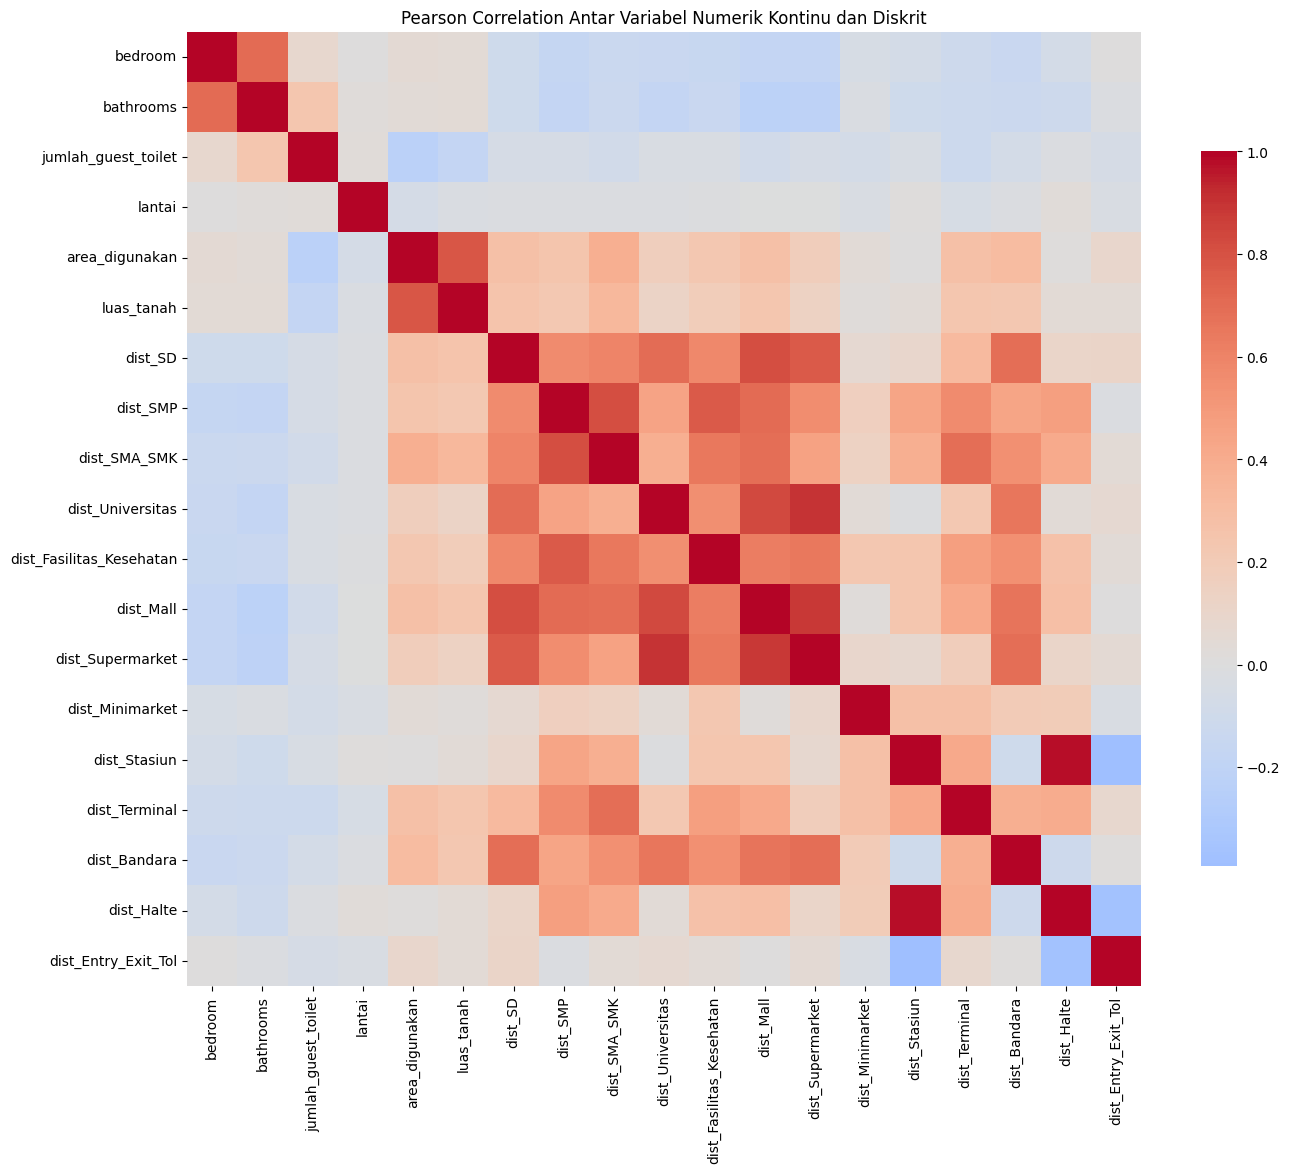

In [7]:
# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_pearson_X,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Pearson Correlation Antar Variabel Numerik Kontinu dan Diskrit")
plt.tight_layout()
plt.show()

# Rekayasa Variabel

In [8]:
df_fe = data.copy()

# FEATURE ENGINEERING BERBASIS JARAK
# Akses transportasi (redundansi tinggi: stasiun - halte - terminal)
df_fe["akses_transportasi"] = df_fe[
    ["dist_Stasiun", "dist_Halte"]
].min(axis=1)

# Akses pendidikan (SMP - SMA/SMK sangat berkorelasi)
df_fe["akses_pendidikan"] = df_fe[
    ["dist_SMP", "dist_SMA_SMK"]
].min(axis=1)

# Akses komersial (mall - supermarket berkorelasi)
df_fe["akses_komersial"] = df_fe[
    ["dist_Mall", "dist_Supermarket"]
].min(axis=1)

# DROP KOLOM LAMA (REDUNDANT)
cols_to_drop = [
    # Transportasi
    "dist_Stasiun", "dist_Halte",    
    # Pendidikan
    "dist_SMP", "dist_SMA_SMK",    
    # Komersial
    "dist_Mall", "dist_Supermarket",    
    
]
df_fe = df_fe.drop(columns=cols_to_drop, errors="ignore")

print("Shape sebelum:", data.shape)
print("Shape sesudah :", df_fe.shape)

Shape sebelum: (916, 83)
Shape sesudah : (916, 80)


In [9]:
df_fe[[
    "akses_transportasi",
    "akses_pendidikan",
    "akses_komersial",
]].describe()

,akses_transportasi,akses_pendidikan,akses_komersial
count,916.000000,916.000000,916.000000
mean,4.066662,2.758814,4.437141
std,2.198999,2.249617,4.656468
min,0.082967,0.160703,0.091586
25%,2.580459,1.218785,1.428185
50%,4.035495,2.075596,2.783398
75%,5.224404,3.601439,4.944646
max,18.018474,15.257932,26.553436


# Final Data

In [11]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 80 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Harga_Asli                         916 non-null    float64
 1   kecamatan                          916 non-null    object 
 2   bedroom                            916 non-null    int64  
 3   bathrooms                          916 non-null    int64  
 4   jumlah_guest_toilet                916 non-null    int64  
 5   lantai                             916 non-null    int64  
 6   area_digunakan                     916 non-null    int64  
 7   luas_tanah                         916 non-null    int64  
 8   latitude                           916 non-null    float64
 9   longitude                          916 non-null    float64
 10  dist_SD                            916 non-null    float64
 11  dist_Universitas                   916 non-null    float64

In [12]:
df_fe.to_csv("C:/skripsi/rev20apr/hitung_manual/output_data/pearson_corr.csv", index=False)

PERHITUNGAN MANUAL PEARSON CORRELATION: dist_Stasiun vs dist_Halte

[INFO] Data Points: 916
[INFO] X variable (dist_Stasiun) - Min: 0.0830, Max: 18.4990, Mean: 4.2232
[INFO] Y variable (dist_Halte) - Min: 0.0846, Max: 18.0185, Mean: 4.1569

[STEP 1] HITUNG MEAN (RATA-RATA) DARI KEDUA VARIABEL

Mean X (dist_Stasiun) = 4.223158
Mean Y (dist_Halte)   = 4.156940

[STEP 2] HITUNG DEVIASI DARI MEAN

Deviasi X (dist_Stasiun - Mean_X) - Sample 5 data pertama:
  [-3.17255204  1.04876061 -2.23282118  2.55957266 -0.06782896]

Deviasi Y (dist_Halte - Mean_Y) - Sample 5 data pertama:
  [-3.10633347  1.06746425 -2.16660262  2.45588352 -0.10183308]

[STEP 3] HITUNG COVARIANCE (KOVARIANSI)

Rumus: Covariance = Σ[(X - Mean_X) × (Y - Mean_Y)] / (n - 1)

Σ[(X - Mean_X) × (Y - Mean_Y)] = 4258.013731
n - 1 = 915
Covariance = 4258.013731 / 915 = 4.653567

[STEP 4] HITUNG STANDAR DEVIASI (STANDARD DEVIATION)

Standar Deviasi X (dist_Stasiun):
  Σ(X - Mean_X)² = 4422.323342
  Std_X = √(4422.323342 / 915) = 2.

,Variabel,Pearson r,P-value,Signifikan
10,dist_Halte,0.977693,0.000000e+00,Ya
1,dist_SMP,0.440186,1.069210e-44,Ya
8,dist_Terminal,0.415861,1.301465e-39,Ya
11,dist_Entry_Exit_Tol,-0.392558,4.066423e-35,Ya
2,dist_SMA_SMK,0.380444,6.423814e-33,Ya
7,dist_Minimarket,0.276172,1.692432e-17,Ya
4,dist_Fasilitas_Kesehatan,0.241324,1.326222e-13,Ya
5,dist_Mall,0.239628,1.983406e-13,Ya
9,dist_Bandara,-0.101099,2.187734e-03,Ya
0,dist_SD,0.088306,7.490531e-03,Ya



[STEP 8] VISUALISASI SCATTER PLOT


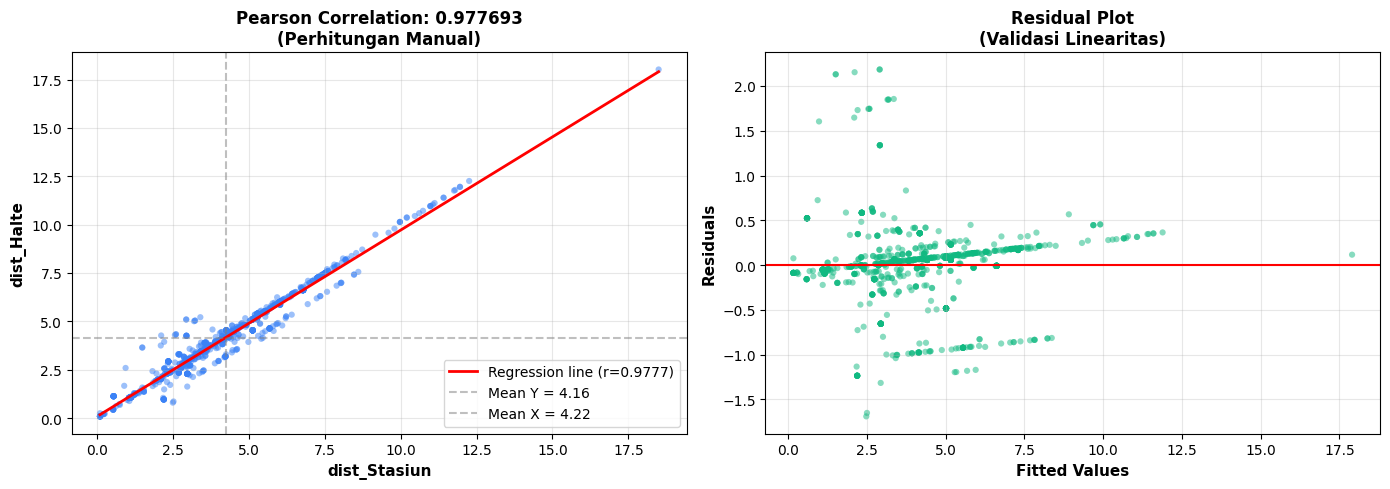


SELESAI: Perhitungan manual Pearson correlation


In [10]:
# PERHITUNGAN MANUAL PEARSON CORRELATION: dist_Stasiun vs dist_Halte
print("="*90)
print("PERHITUNGAN MANUAL PEARSON CORRELATION: dist_Stasiun vs dist_Halte")
print("="*90)

# Ambil kedua variabel
x_var = X['dist_Stasiun'].values
y_var = X['dist_Halte'].values
n = len(x_var)

print(f"\n[INFO] Data Points: {n}")
print(f"[INFO] X variable (dist_Stasiun) - Min: {x_var.min():.4f}, Max: {x_var.max():.4f}, Mean: {x_var.mean():.4f}")
print(f"[INFO] Y variable (dist_Halte) - Min: {y_var.min():.4f}, Max: {y_var.max():.4f}, Mean: {y_var.mean():.4f}")

# ============================================================================
# STEP 1: HITUNG MEAN DARI KEDUA VARIABEL
# ============================================================================
print("\n" + "="*90)
print("[STEP 1] HITUNG MEAN (RATA-RATA) DARI KEDUA VARIABEL")
print("="*90)

mean_x = np.mean(x_var)
mean_y = np.mean(y_var)

print(f"\nMean X (dist_Stasiun) = {mean_x:.6f}")
print(f"Mean Y (dist_Halte)   = {mean_y:.6f}")

# ============================================================================
# STEP 2: HITUNG DEVIASI (X - Mean_X) DAN (Y - Mean_Y)
# ============================================================================
print("\n" + "="*90)
print("[STEP 2] HITUNG DEVIASI DARI MEAN")
print("="*90)

dev_x = x_var - mean_x  # Deviasi X
dev_y = y_var - mean_y  # Deviasi Y

print(f"\nDeviasi X (dist_Stasiun - Mean_X) - Sample 5 data pertama:")
print(f"  {dev_x[:5]}")
print(f"\nDeviasi Y (dist_Halte - Mean_Y) - Sample 5 data pertama:")
print(f"  {dev_y[:5]}")

# ============================================================================
# STEP 3: HITUNG COVARIANCE (KOVARIANSI)
# ============================================================================
print("\n" + "="*90)
print("[STEP 3] HITUNG COVARIANCE (KOVARIANSI)")
print("="*90)

# Covariance = Σ[(X - Mean_X) * (Y - Mean_Y)] / (n - 1)
product_deviations = dev_x * dev_y
sum_product_deviations = np.sum(product_deviations)
covariance = sum_product_deviations / (n - 1)

print(f"\nRumus: Covariance = Σ[(X - Mean_X) × (Y - Mean_Y)] / (n - 1)")
print(f"\nΣ[(X - Mean_X) × (Y - Mean_Y)] = {sum_product_deviations:.6f}")
print(f"n - 1 = {n - 1}")
print(f"Covariance = {sum_product_deviations:.6f} / {n - 1} = {covariance:.6f}")

# ============================================================================
# STEP 4: HITUNG STANDAR DEVIASI KEDUA VARIABEL
# ============================================================================
print("\n" + "="*90)
print("[STEP 4] HITUNG STANDAR DEVIASI (STANDARD DEVIATION)")
print("="*90)

# Standard Deviation = √[Σ(X - Mean_X)² / (n - 1)]
sum_sq_dev_x = np.sum(dev_x ** 2)
sum_sq_dev_y = np.sum(dev_y ** 2)

std_x = np.sqrt(sum_sq_dev_x / (n - 1))
std_y = np.sqrt(sum_sq_dev_y / (n - 1))

print(f"\nStandar Deviasi X (dist_Stasiun):")
print(f"  Σ(X - Mean_X)² = {sum_sq_dev_x:.6f}")
print(f"  Std_X = √({sum_sq_dev_x:.6f} / {n - 1}) = {std_x:.6f}")

print(f"\nStandar Deviasi Y (dist_Halte):")
print(f"  Σ(Y - Mean_Y)² = {sum_sq_dev_y:.6f}")
print(f"  Std_Y = √({sum_sq_dev_y:.6f} / {n - 1}) = {std_y:.6f}")

# ============================================================================
# STEP 5: HITUNG PEARSON CORRELATION COEFFICIENT
# ============================================================================
print("\n" + "="*90)
print("[STEP 5] HITUNG PEARSON CORRELATION COEFFICIENT")
print("="*90)

# Pearson r = Covariance(X, Y) / (Std_X * Std_Y)
pearson_r_manual = covariance / (std_x * std_y)

print(f"\nRumus: Pearson r = Covariance(X,Y) / (Std_X × Std_Y)")
print(f"\nPearson r = {covariance:.6f} / ({std_x:.6f} × {std_y:.6f})")
print(f"Pearson r = {covariance:.6f} / {std_x * std_y:.6f}")
print(f"\n>>> PEARSON CORRELATION = {pearson_r_manual:.6f} <<<")

# ============================================================================
# STEP 6: VERIFIKASI DENGAN LIBRARY SCIPY/NUMPY
# ============================================================================
print("\n" + "="*90)
print("[STEP 6] VERIFIKASI HASIL DENGAN LIBRARY")
print("="*90)

from scipy.stats import pearsonr
from scipy.stats import spearmanr

pearson_r_scipy, p_value_pearson = pearsonr(x_var, y_var)
spearman_r, p_value_spearman = spearmanr(x_var, y_var)

print(f"\nHasil dari scipy.stats.pearsonr:")
print(f"  Pearson r = {pearson_r_scipy:.6f}")
print(f"  P-value = {p_value_pearson:.6e}")
print(f"  Signifikansi: {'Signifikan (p < 0.05)' if p_value_pearson < 0.05 else 'Tidak signifikan (p >= 0.05)'}")

print(f"\nPerbandingan Manual vs Library:")
print(f"  Manual calculation: {pearson_r_manual:.6f}")
print(f"  Scipy calculation: {pearson_r_scipy:.6f}")
print(f"  Perbedaan: {abs(pearson_r_manual - pearson_r_scipy):.2e}")

# Correlation strength interpretation
print(f"\nInterpretasi Kekuatan Korelasi (|r|):")
if abs(pearson_r_manual) >= 0.9:
    strength = "Sangat Kuat"
elif abs(pearson_r_manual) >= 0.7:
    strength = "Kuat"
elif abs(pearson_r_manual) >= 0.5:
    strength = "Sedang"
elif abs(pearson_r_manual) >= 0.3:
    strength = "Lemah"
else:
    strength = "Sangat Lemah / Tidak ada"

direction = "Positif (berbanding lurus)" if pearson_r_manual > 0 else "Negatif (berbanding terbalik)"
print(f"  |r| = {abs(pearson_r_manual):.4f} → {strength}")
print(f"  Arah: {direction}")

# ============================================================================
# STEP 7: TABEL PERBANDINGAN KORELASI DENGAN VARIABEL LAIN
# ============================================================================
print("\n" + "="*90)
print("[STEP 7] PERBANDINGAN KORELASI dist_Stasiun vs VARIABEL LAIN")
print("="*90)

# Ambil semua kolom dist_ dan hitung korelasinya
dist_cols = [col for col in X.columns if col.startswith('dist_')]

correlation_results = []
for col in dist_cols:
    if col != 'dist_Stasiun':
        r, p_val = pearsonr(X['dist_Stasiun'], X[col])
        correlation_results.append({
            'Variabel': col,
            'Pearson r': r,
            'P-value': p_val,
            'Signifikan': 'Ya' if p_val < 0.05 else 'Tidak'
        })

corr_df = pd.DataFrame(correlation_results).sort_values('Pearson r', ascending=False, key=abs)
display(corr_df)

# ============================================================================
# STEP 8: VISUALISASI SCATTER PLOT + REGRESSION LINE
# ============================================================================
print("\n[STEP 8] VISUALISASI SCATTER PLOT")
print("="*90)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot 1: Manual dengan garis regresi
from numpy.polynomial import Polynomial
p = Polynomial.fit(x_var, y_var, 1)
x_line = np.linspace(x_var.min(), x_var.max(), 100)
y_line = p(x_line)

axes[0].scatter(x_var, y_var, alpha=0.5, s=20, color='#3B82F6', edgecolor='none')
axes[0].plot(x_line, y_line, 'r-', linewidth=2, label=f'Regression line (r={pearson_r_manual:.4f})')
axes[0].axhline(mean_y, color='gray', linestyle='--', alpha=0.5, label=f'Mean Y = {mean_y:.2f}')
axes[0].axvline(mean_x, color='gray', linestyle='--', alpha=0.5, label=f'Mean X = {mean_x:.2f}')
axes[0].set_xlabel('dist_Stasiun', fontsize=11, fontweight='bold')
axes[0].set_ylabel('dist_Halte', fontsize=11, fontweight='bold')
axes[0].set_title(f'Pearson Correlation: {pearson_r_manual:.6f}\n(Perhitungan Manual)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot 2: Residuals plot
residuals = y_var - p(x_var)
axes[1].scatter(p(x_var), residuals, alpha=0.5, s=20, color='#10B981', edgecolor='none')
axes[1].axhline(0, color='red', linestyle='-', linewidth=1.5)
axes[1].set_xlabel('Fitted Values', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[1].set_title('Residual Plot\n(Validasi Linearitas)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("SELESAI: Perhitungan manual Pearson correlation")
print("="*90)